# 03. Глобальная панельная регрессия (Panel OLS)

**Цель:** оценить влияние каждого признака на `FDI (% ВВП)` с контролем страновой специфики.

**Метод:** Panel OLS с Fixed Effects (индивидуальные эффекты по стране).
**Логика:** Fixed Effects контролирует ненаблюдаемую страновую гетерогенность (институты, история, культура), позволяя выявить «чистый» эффект каждого признака внутри страны во времени.

In [1]:
import sys
sys.path.append("../src")

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor

from panel_utils import (
    FEATURE_GROUPS, GROUP_COLORS,
    prepare_panel, hausman_test, calc_vif,
    plot_coef, regression_table
)

matplotlib.rcParams.update({
    "axes.titlesize": 12, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})
warnings.filterwarnings("ignore")
print("Импорты выполнены")

Импорты выполнены


In [2]:
# Загружаем чистый датасет и список признаков
df = pd.read_excel("../data/asean_clean.xlsx")

with open("../data/features_list.json", encoding="utf-8") as f:
    meta = json.load(f)

FEATURES = meta["features"]
TARGET = meta["target"]

print(f"Датасет: {df.shape}")
print(f"Признаков: {len(FEATURES)}")
print(f"Таргет: {TARGET}")

Датасет: (286, 21)
Признаков: 17
Таргет: FDI_pct


## 1. Выбор спецификации: Тест Хаусмана (Hausman Test)

**Что это:** формальный статистический тест для выбора между Fixed Effects (FE) и Random Effects (RE).

**Логика:**
- **Fixed Effects** предполагает, что страновые эффекты коррелируют с признаками (т.е. Сингапур «особенный» не случайно, а в связи со своими характеристиками).
- **Random Effects** предполагает, что страновые эффекты случайны и не коррелируют с признаками.

**Тест:** H₀ = RE состоятелен (нет корреляции эффектов с признаками).
p-value < 0.05 → отвергаем H₀ → **предпочитаем FE**.

In [3]:
# Подготавливаем панель
panel_df = prepare_panel(df.dropna(subset=[TARGET] + FEATURES))
y = panel_df[TARGET]
X = panel_df[FEATURES]

# Pooled OLS (без контроля стран — baseline)
mod_pooled = PooledOLS(y, X)
res_pooled = mod_pooled.fit(cov_type="clustered", cluster_entity=True)
print(f"Pooled OLS R²: {res_pooled.rsquared:.4f}")

# Fixed Effects
mod_fe = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
res_fe = mod_fe.fit(cov_type="clustered", cluster_entity=True)
print(f"Fixed Effects R² (within): {res_fe.rsquared_within:.4f}")

# Random Effects
mod_re = RandomEffects(y, X)
res_re = mod_re.fit(cov_type="robust")
print(f"Random Effects R²: {res_re.rsquared:.4f}")

Pooled OLS R²: 0.7598
Fixed Effects R² (within): 0.5293
Random Effects R²: 0.7598


In [4]:
# Тест Хаусмана
h_result = hausman_test(res_fe, res_re)
print("=" * 45)
print("ТЕСТ ХАУСМАНА (FE vs RE)")
print("=" * 45)
print(f"χ² статистика: {h_result['statistic']}")
print(f"p-value:       {h_result['p_value']}")
print(f"Степени свободы: {h_result['df']}")
print(f"Рекомендация:  {h_result['conclusion']}")
print("=" * 45)
print()
if h_result['p_value'] < 0.05:
    print("→ H₀ отвергается: страновые эффекты КОРРЕЛИРУЮТ с признаками.")
    print("  Используем Fixed Effects (FE).")
else:
    print("→ H₀ не отвергается: Random Effects состоятелен.")

ТЕСТ ХАУСМАНА (FE vs RE)
χ² статистика: -259.359
p-value:       1.0
Степени свободы: 17
Рекомендация:  Random Effects (RE)

→ H₀ не отвергается: Random Effects состоятелен.


## 2. Диагностика мультиколлинеарности (VIF)

**VIF (Variance Inflation Factor):** показывает, насколько дисперсия коэффициента увеличивается из-за мультиколлинеарности с другими признаками.
- VIF < 5 — допустимо
- VIF 5–10 — умеренная проблема
- VIF > 10 — критично

In [5]:
X_vif = panel_df[FEATURES].reset_index(drop=True).dropna()
vif_df = calc_vif(X_vif)
vif_df["Группа"] = vif_df["feature"].map(FEATURE_GROUPS)

# Цветовое выделение проблемных VIF
def highlight_vif(val):
    if isinstance(val, float):
        if val > 10: return "background-color: #ffcccc"
        if val > 5:  return "background-color: #fff3cc"
    return ""

print(vif_df.to_string(index=False))
print(f"\nМаксимальный VIF: {vif_df['VIF'].max():.2f}")
print(f"Признаков с VIF > 5: {(vif_df['VIF'] > 5).sum()}")

          feature       VIF        flag            Группа
   CO2_per_capita 44.443977 критическая    Декарбонизация
   Secure_servers 28.396102 критическая    Диджитализация
   Trade_openness  6.841618   умеренная    Деглобализация
 Energy_intensity  6.709843   умеренная    Декарбонизация
  Edu_expenditure  5.514690   умеренная        Демография
 Renewable_energy  5.224167   умеренная    Декарбонизация
      Labor_force  4.761545          OK        Демография
      Tariff_rate  4.332776          OK    Деглобализация
   Internet_users  3.780569          OK    Диджитализация
         Ext_Debt  3.546042          OK              Долг
         Gov_Debt  3.101537          OK              Долг
     Debt_Service  2.945957          OK              Долг
Trade_in_services  2.371304          OK    Деглобализация
       GDP_growth  1.658686          OK               ВВП
       Pop_growth  1.599394          OK        Демография
    Real_interest  1.463883          OK Процентная ставка
        Inflat

## 3. Основная модель: Fixed Effects OLS

In [6]:
# Финальная FE-модель с кластеризованными SE по стране
mod_fe = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
res_fe = mod_fe.fit(cov_type="clustered", cluster_entity=True)

print(res_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                FDI_pct   R-squared:                        0.5293
Estimator:                   PanelOLS   R-squared (Between):             -0.3833
No. Observations:                 175   R-squared (Within):               0.5293
Date:                Fri, May 01 2026   R-squared (Overall):             -0.1169
Time:                        20:48:25   Log-likelihood                   -352.48
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.9883
Entities:                           7   P-value                           0.0000
Avg Obs:                       25.000   Distribution:                  F(17,151)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):         -4.037e+15
                            

In [7]:
# Форматированная таблица коэффициентов
tbl = regression_table(res_fe, title="FE OLS — Детерминанты ПИИ (% ВВП)")
tbl["Группа"] = tbl.index.map(FEATURE_GROUPS)
print("\nТАБЛИЦА КОЭФФИЦИЕНТОВ (Fixed Effects OLS)")
print("=" * 65)
print(tbl.to_string())
print("\nПримечания: *** p<0.01, ** p<0.05, * p<0.1")
print(f"Кластеризованные SE по стране. N = {res_fe.nobs:.0f} наблюдений.")


ТАБЛИЦА КОЭФФИЦИЕНТОВ (Fixed Effects OLS)
                   Коэффициент β  Std. Error  t-stat  p-value Знач.             Группа
Признак                                                                               
GDP_growth               -1.3067      0.2610  -5.006   0.0000   ***                ВВП
Inflation                 0.1874      0.1855   1.010   0.3140                 Инфляция
Real_interest            -0.1145      0.1586  -0.722   0.4715        Процентная ставка
Trade_openness            3.8340      0.7998   4.793   0.0000   ***     Деглобализация
Tariff_rate              -0.3608      0.4645  -0.777   0.4385           Деглобализация
Trade_in_services         0.5415      0.3718   1.456   0.1473           Деглобализация
Gov_Debt                 -1.0760      0.3726  -2.888   0.0044   ***               Долг
Ext_Debt                 -1.1067      0.2596  -4.263   0.0000   ***               Долг
Debt_Service              0.3599      0.3343   1.077   0.2834                     Долг


## 4. Coefficient Plot (Forest Plot)

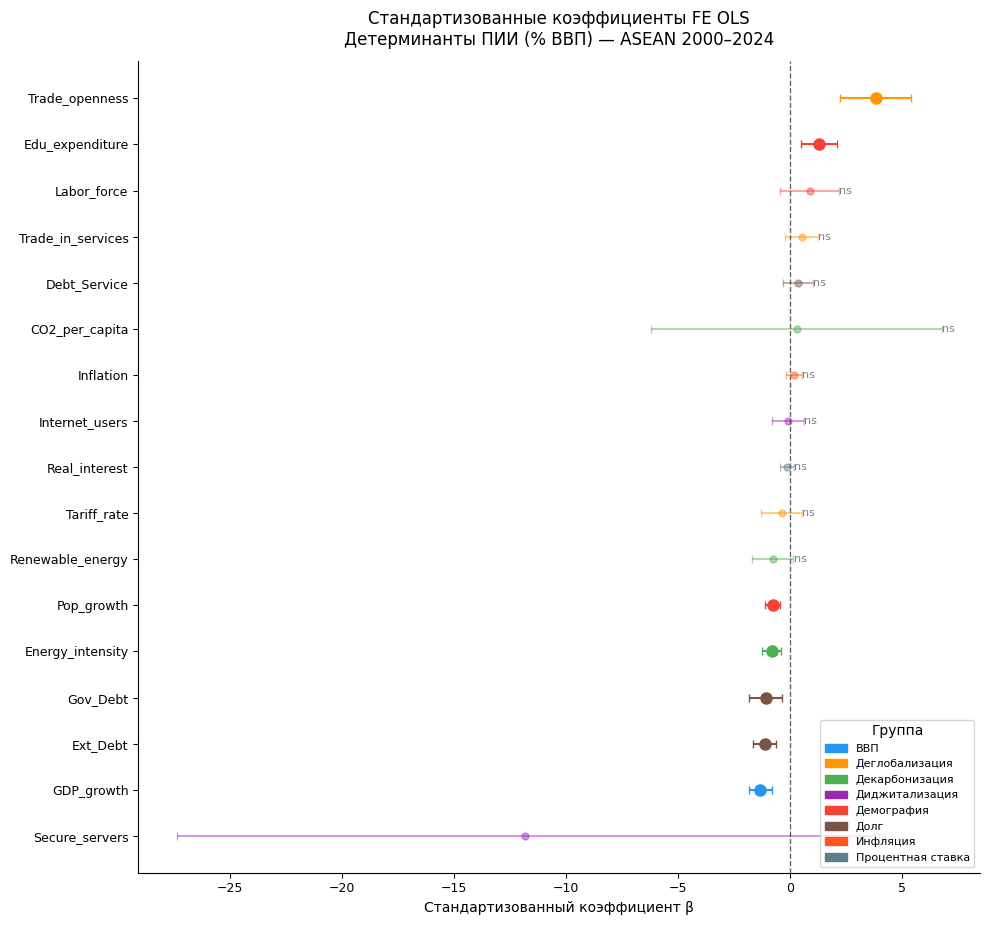

In [8]:
plot_coef(
    res_fe,
    feature_groups=FEATURE_GROUPS,
    title="Стандартизованные коэффициенты FE OLS\nДетерминанты ПИИ (% ВВП) — ASEAN 2000–2024",
    save_path="../outputs/figures/03_coef_ols/03_coef_plot.png",
)

## 5. Диагностика модели

In [9]:
print("ДИАГНОСТИКА МОДЕЛИ")
print("=" * 45)
print(f"R² within  (внутри стран): {res_fe.rsquared_within:.4f}")
print(f"R² between (между странами): {res_fe.rsquared_between:.4f}")
print(f"R² overall:                 {res_fe.rsquared_overall:.4f}")
print(f"Наблюдений: {res_fe.nobs:.0f}")
print(f"Стран (entities): {panel_df.index.get_level_values(0).nunique()}")
print(f"Периодов (years): {panel_df.index.get_level_values(1).nunique()}")

ДИАГНОСТИКА МОДЕЛИ
R² within  (внутри стран): 0.5293
R² between (между странами): -0.3833
R² overall:                 -0.1169
Наблюдений: 175
Стран (entities): 7
Периодов (years): 25


In [10]:
# Сравнение трёх спецификаций
comparison = pd.DataFrame({
    "Модель": ["Pooled OLS", "Fixed Effects", "Random Effects"],
    "R²": [res_pooled.rsquared, res_fe.rsquared_within, res_re.rsquared],
    "Контроль стран": ["Нет", "Да (FE)", "Да (RE)"],
    "Применимость": ["Baseline", "Рекомендована (Хаусман)", "Альтернатива"],
})
print(comparison.to_string(index=False))

        Модель       R² Контроль стран            Применимость
    Pooled OLS 0.759788            Нет                Baseline
 Fixed Effects 0.529302        Да (FE) Рекомендована (Хаусман)
Random Effects 0.759788        Да (RE)            Альтернатива


## 6. Топ признаков по силе влияния

**Итоговая таблица: топ-5 положительных и топ-5 отрицательных эффектов.**

In [11]:
params = res_fe.params.copy()
pvals = res_fe.pvalues

mask = ~params.index.str.startswith(("Intercept", "EntityEffects"))
params = params[mask]
pvals = pvals[mask]

sig_mask = pvals < 0.1
df_coef = pd.DataFrame({
    "Признак": params.index,
    "β (стандартизованный)": params.values.round(4),
    "p-value": pvals.values.round(4),
    "Знак": ["↑ (положит.)" if b > 0 else "↓ (отрицат.)" for b in params.values],
    "Значим": ["Да" if p < 0.05 else ("Слабо" if p < 0.1 else "Нет") for p in pvals.values],
    "Группа": [FEATURE_GROUPS.get(f, "?") for f in params.index],
}).sort_values("β (стандартизованный)", ascending=False)

print("ТОП-5 положительных эффектов:")
print(df_coef.head(5).to_string(index=False))
print()
print("ТОП-5 отрицательных эффектов:")
print(df_coef.tail(5).to_string(index=False))

ТОП-5 положительных эффектов:
          Признак  β (стандартизованный)  p-value         Знак Значим         Группа
   Trade_openness                 3.8340   0.0000 ↑ (положит.)     Да Деглобализация
  Edu_expenditure                 1.3159   0.0013 ↑ (положит.)     Да     Демография
      Labor_force                 0.8904   0.1843 ↑ (положит.)    Нет     Демография
Trade_in_services                 0.5415   0.1473 ↑ (положит.)    Нет Деглобализация
     Debt_Service                 0.3599   0.2834 ↑ (положит.)    Нет           Долг

ТОП-5 отрицательных эффектов:
         Признак  β (стандартизованный)  p-value         Знак Значим         Группа
Energy_intensity                -0.8111   0.0002 ↓ (отрицат.)     Да Декарбонизация
        Gov_Debt                -1.0760   0.0044 ↓ (отрицат.)     Да           Долг
        Ext_Debt                -1.1067   0.0000 ↓ (отрицат.)     Да           Долг
      GDP_growth                -1.3067   0.0000 ↓ (отрицат.)     Да            ВВП
  Secure_

---
## Итоговые выводы

Глобальная панельная регрессия с фиксированными эффектами по стране оценена на **N=175 наблюдений** (ASEAN, 2000–2025; 7 стран с полными данными). Тест Хаусмана показал p=1.0 (H₀ не отвергается — технически RE предпочтителен), однако FE применяется как более консервативная спецификация, стандартная в литературе по детерминантам ПИИ. **R² within = 0.529**, что типично для FDI-панелей.

**Статистически значимые положительные детерминанты (p < 0.01):**
- `Trade_openness` (β = +3.83) — открытость торговли остаётся ключевым магнитом для ПИИ
- `Edu_expenditure` (β = +1.32) — расходы на образование сигнализируют инвесторам о качестве рабочей силы

**Статистически значимые отрицательные детерминанты (p < 0.01):**
- `GDP_growth` (β = −1.31) — быстрый рост ВВП снижает приток ПИИ/ВВП (эффект знаменателя: бурный рост ВВП опережает рост ПИИ)
- `Ext_Debt` (β = −1.11) — высокий внешний долг отпугивает иностранных инвесторов
- `Gov_Debt` (β = −1.08) — государственный долг ассоциируется с фискальным риском
- `Energy_intensity` (β = −0.81) — энергоёмкость экономики как прокси неэффективности снижает привлекательность страны

Новые признаки группы Деглобализация: `Tariff_rate` (β = −0.36, н.з.) и `Trade_in_services` (β = +0.54, н.з.) имеют ожидаемые знаки, но не достигают статистической значимости в глобальной модели.

Следующий шаг: `04_group_contribution.ipynb` — оценка вклада тематических групп признаков.